# FinRobot Integrated Quality Filter — v3
### GR5398 Final Assignment — FinRobot Module

**v3 additions over v2:**
- `ResearchScore` dataclass: 4 structured dimensions + composite score
- Claude critic prompt forces explicit 4-dimension scoring
- Composite score formula: `business_quality×0.30 + valuation×0.20 + catalyst×0.30 + (10−risk)×0.20`
- Weight multiplier: composite score drives continuous position sizing (not just approve/reject)
- `scores_df` output: directly plugs into `portfolio_builder` of AdaptiveRotationEngine

**Stock universe:**

| Group | Tickers | Type |
|---|---|---|
| Precious Metals | GLD / SLV / IAU | ETF |
| Tech / Consumer | AMZN / AAPL | Equity |
| Energy / Utilities | COP / XLU | Equity + ETF |

**3-stage pipeline:**

| Stage | Model | Role |
|---|---|---|
| Stage 1 — Perplexity | Perplexity Sonar Pro | Real-time grounding (ETF-aware) |
| Stage 2 — Gemini | Gemini 2.5 Pro | 8-section analyst draft |
| Stage 3 — Claude | Claude Sonnet | 4-dimension scoring + section revision |

**Backtest schedule:** 2026-01-05 → 02-02 → 03-02 → 04-06

## 1. Setup & Dependencies

In [1]:
!pip install pyautogen yfinance pandas matplotlib -q

In [2]:
import os
import re
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import yfinance as yf
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import Dict, List, Tuple, Optional
from autogen import AssistantAgent, UserProxyAgent

print("✓ Imports OK")

✓ Imports OK


C:\Users\wujie\anaconda3\envs\finrobot\lib\site-packages\flaml\__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")


## 2. API Keys

In [3]:
os.environ["OPENROUTER_API_KEY"] = "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"
print("OPENROUTER_API_KEY set:", bool(os.getenv("OPENROUTER_API_KEY")))

OPENROUTER_API_KEY set: True


## 3. ResearchScore — Structured Score Object

Core data structure. All four dimensions are scored 1–10 by Claude critic.  
Composite score drives portfolio weight multipliers in the trading pipeline.

In [4]:
@dataclass
class ResearchScore:
    """
    Structured research score for one ticker at one rebalance date.
    All dimension scores are 1-10 (higher = better, except risk where higher = more risky).
    Composite is normalized to 0-1 for pipeline weight calculation.

    Dimension weights (sum to 1.0):
        business_quality : 0.30  — moat, revenue quality, margin profile
        valuation        : 0.20  — current price vs fair value
        catalyst         : 0.30  — near-term catalysts, timing, probability
        risk             : 0.20  — inverted: (10 - risk_score) used in composite
    """
    ticker:           str
    as_of_date:       str
    is_etf:           bool

    # Dimension scores (1-10 each, from Claude critic)
    business_quality: float = 5.0   # moat / macro quality for ETFs
    valuation:        float = 5.0   # price vs fair value / NAV premium
    catalyst:         float = 5.0   # near-term catalyst strength
    risk:             float = 5.0   # risk level (10 = highest risk)

    # Derived
    composite:        float = 0.5   # normalized 0-1, drives weight multiplier
    verdict:          str   = "NEUTRAL"  # YES / NO / REDUCE_WEIGHT / NEUTRAL
    parse_ok:         bool  = False  # True if all 4 dims parsed successfully

    def compute_composite(self) -> float:
        """
        composite = (bq×0.30 + val×0.20 + cat×0.30 + (10-risk)×0.20) / 10
        Returns value in [0, 1].
        """
        raw = (
            self.business_quality * 0.30 +
            self.valuation        * 0.20 +
            self.catalyst         * 0.30 +
            (10 - self.risk)      * 0.20
        )
        return round(min(max(raw / 10.0, 0.0), 1.0), 4)

    def weight_multiplier(self, base: float = 1.0, scale: float = 2.0) -> float:
        """
        Convert composite score to a portfolio weight multiplier.

        Formula: multiplier = base + (composite - 0.5) * scale
        - composite = 0.5 (neutral) → multiplier = base (1.0x)
        - composite = 1.0 (max)     → multiplier = base + 0.5*scale (2.0x)
        - composite = 0.0 (min)     → multiplier = base - 0.5*scale (0.0x)
        - verdict = NO              → multiplier = 0.0 (excluded)
        - verdict = REDUCE_WEIGHT   → multiplier capped at 0.5

        Args:
            base:  center multiplier (default 1.0)
            scale: range of adjustment (default 2.0, gives 0x to 2x)
        """
        if self.verdict == "NO":
            return 0.0
        mult = base + (self.composite - 0.5) * scale
        mult = max(0.0, mult)
        if self.verdict == "REDUCE_WEIGHT":
            mult = min(mult, 0.5)
        return round(mult, 4)

    def to_pipeline_dict(self) -> dict:
        """Flat dict for direct injection into portfolio_builder."""
        return {
            "ticker":           self.ticker,
            "as_of_date":       self.as_of_date,
            "is_etf":           self.is_etf,
            "business_quality": self.business_quality,
            "valuation":        self.valuation,
            "catalyst":         self.catalyst,
            "risk":             self.risk,
            "composite":        self.composite,
            "verdict":          self.verdict,
            "weight_mult":      self.weight_multiplier(),
            "include":          self.verdict != "NO",
            "parse_ok":         self.parse_ok,
        }


# ── Score parsing from Claude critic output ───────────────────────────────────

def parse_dimension_scores(critic_output: str) -> Dict[str, float]:
    """
    Extract all four dimension scores from Claude critic output.
    Expects lines like:
        BUSINESS QUALITY SCORE: 8/10
        VALUATION SCORE: 6/10
        CATALYST SCORE: 7/10
        RISK SCORE: 4/10
    Returns dict with keys: business_quality, valuation, catalyst, risk.
    """
    patterns = {
        "business_quality": r"BUSINESS\s+QUALITY\s+SCORE[:\s]+([\d.]+)\s*/\s*10",
        "valuation":         r"VALUATION\s+SCORE[:\s]+([\d.]+)\s*/\s*10",
        "catalyst":          r"CATALYST\s+SCORE[:\s]+([\d.]+)\s*/\s*10",
        "risk":              r"RISK\s+SCORE[:\s]+([\d.]+)\s*/\s*10",
    }
    scores = {}
    for key, pattern in patterns.items():
        m = re.search(pattern, critic_output, re.IGNORECASE)
        scores[key] = float(m.group(1)) if m else None
    return scores


def parse_verdict(critic_output: str) -> str:
    m = re.search(
        r"INCLUDE\s+IN\s+PORTFOLIO[:\s]*(YES|NO|REDUCE_WEIGHT)",
        critic_output, re.IGNORECASE
    )
    return m.group(1).upper() if m else "NEUTRAL"


def build_research_score(ticker: str, as_of_date: str, is_etf: bool,
                         critic_output: str) -> ResearchScore:
    """
    Parse Claude critic output into a ResearchScore object.
    Falls back to 5.0 for any dimension that fails to parse.
    """
    dims   = parse_dimension_scores(critic_output)
    verdict = parse_verdict(critic_output)
    parse_ok = all(v is not None for v in dims.values())

    score = ResearchScore(
        ticker           = ticker,
        as_of_date       = as_of_date,
        is_etf           = is_etf,
        business_quality = dims.get("business_quality") or 5.0,
        valuation        = dims.get("valuation")        or 5.0,
        catalyst         = dims.get("catalyst")         or 5.0,
        risk             = dims.get("risk")             or 5.0,
        verdict          = verdict,
        parse_ok         = parse_ok,
    )
    score.composite = score.compute_composite()
    return score


# Quick unit test
test_score = ResearchScore(ticker="TEST", as_of_date="2026-01-05", is_etf=False,
                           business_quality=8, valuation=7, catalyst=9, risk=3,
                           verdict="YES")
test_score.composite = test_score.compute_composite()
print(f"Unit test — composite={test_score.composite:.4f}  mult={test_score.weight_multiplier():.4f}")
print(f"  expected composite = (8×0.3 + 7×0.2 + 9×0.3 + 7×0.2)/10 = {(8*0.3+7*0.2+9*0.3+7*0.2)/10:.4f}")
print("✓ ResearchScore ready")

Unit test — composite=0.7900  mult=1.5800
  expected composite = (8×0.3 + 7×0.2 + 9×0.3 + 7×0.2)/10 = 0.7900
✓ ResearchScore ready


## 4. Universe & Backtest Schedule

In [5]:
UNIVERSE = {
    "Precious Metals":    ["GLD", "SLV", "IAU"],
    "Tech / Consumer":    ["AMZN", "AAPL"],
    "Energy / Utilities": ["COP", "XLU"],
}
ALL_CANDIDATES = [t for tickers in UNIVERSE.values() for t in tickers]
ETF_TICKERS    = {"GLD", "SLV", "IAU", "XLU", "SPY", "QQQ", "IWM", "TLT"}

REBALANCE_DATES = [
    "2026-01-05",
    "2026-02-02",
    "2026-03-02",
    "2026-04-06",
]

QUALITY_THRESHOLD = 0.50   # composite score minimum for inclusion
MAX_STOCKS        = 10

print("Universe:")
for group, tickers in UNIVERSE.items():
    flags = ["ETF" if t in ETF_TICKERS else "EQ" for t in tickers]
    print(f"  {group:25s}: {', '.join(f'{t}({f})' for t, f in zip(tickers, flags))}")
print(f"\nRebalance dates : {REBALANCE_DATES}")
print(f"Threshold       : composite >= {QUALITY_THRESHOLD}")

Universe:
  Precious Metals          : GLD(ETF), SLV(ETF), IAU(ETF)
  Tech / Consumer          : AMZN(EQ), AAPL(EQ)
  Energy / Utilities       : COP(EQ), XLU(ETF)

Rebalance dates : ['2026-01-05', '2026-02-02', '2026-03-02', '2026-04-06']
Threshold       : composite >= 0.5


## 5. Model Configurations

In [6]:
def make_perplexity_config():
    return {"model": "perplexity/sonar-pro",
            "api_key": os.getenv("OPENROUTER_API_KEY"),
            "base_url": "https://openrouter.ai/api/v1"}

def make_gemini_config():
    return {"model": "google/gemini-2.5-pro-preview-05-06",
            "api_key": os.getenv("OPENROUTER_API_KEY"),
            "base_url": "https://openrouter.ai/api/v1"}

def make_claude_config():
    return {"model": "anthropic/claude-sonnet-4-6",
            "api_key": os.getenv("OPENROUTER_API_KEY"),
            "base_url": "https://openrouter.ai/api/v1"}

print("Stage 1:", make_perplexity_config()["model"])
print("Stage 2:", make_gemini_config()["model"])
print("Stage 3:", make_claude_config()["model"])

Stage 1: perplexity/sonar-pro
Stage 2: google/gemini-2.5-pro-preview-05-06
Stage 3: anthropic/claude-sonnet-4-6


## 6. Prompts

Key change in v3: **Claude critic prompt now requires explicit 4-dimension scoring block** in a fixed format that the parser can reliably extract.

In [7]:
# ── Stage 1a: Equity ─────────────────────────────────────────────────────────
PERPLEXITY_EQUITY_SYSTEM = """You are an equity research analyst with real-time web search.
Today's date: {as_of_date}.

Search for and report:
1. Latest earnings / guidance (Q4 2025 or Q1 2026)
2. Analyst rating changes (last 60 days) with price targets
3. Key catalysts: products, partnerships, contracts, regulatory events
4. Major risks currently in the news
5. Competitive position vs 2-3 peers
6. Notable insider activity or institutional flows

Bull/bear thesis (200-300 words), then:
QUALITY VERDICT: [STRONG / NEUTRAL / WEAK] — [one sentence]
Cite sources with dates."""

# ── Stage 1b: ETF ─────────────────────────────────────────────────────────────
PERPLEXITY_ETF_SYSTEM = """You are a macro/ETF analyst with real-time web search.
Today's date: {as_of_date}.
This is an ETF — do NOT discuss earnings.

Search for and report:
1. Fund flows (inflows/outflows last 30-60 days)
2. Key macro drivers:
   - Metals ETFs (GLD/SLV/IAU): Fed policy, real rates, USD, inflation expectations
   - Utilities ETF (XLU): rate environment, dividend yield vs bonds, recession signals
3. Relative price momentum vs SPY
4. Geopolitical / macro news affecting the asset class
5. Key macro risk that would hurt this position

Bull/bear thesis (200-300 words), then:
QUALITY VERDICT: [STRONG / NEUTRAL / WEAK] — [one sentence macro reason]
Cite sources with dates."""

# ── Stage 2: Gemini analyst draft ────────────────────────────────────────────
GEMINI_ANALYST_SYSTEM = """You are a structured equity/ETF research analyst.
Write a full research report with EXACTLY these 8 sections:

## TAGLINE
## OVERVIEW
## INVESTMENT OVERVIEW
## VALUATION OVERVIEW
## RISKS
## COMPETITOR ANALYSIS
## MAJOR TAKEAWAYS
## NEWS SUMMARY

For ETFs: replace earnings references with macro drivers and fund flows.
Use specific numbers from the data. Do not invent figures."""

# ── Stage 3: Claude critic — v3 adds mandatory 4-dimension scoring block ──────
CLAUDE_CRITIC_PROMPT = """You are a senior research critic (role_mixed_b critic role).

Task for {ticker} ({name}):
1. Revise THREE sections: INVESTMENT OVERVIEW, RISKS, MAJOR TAKEAWAYS
2. Output a structured SCORECARD with exactly four dimension scores

Revision rules:
- Keep factual consistency — do not invent figures
- Strengthen risk specificity and catalyst clarity
- Make MAJOR TAKEAWAYS actionable for a portfolio manager
- For ETFs: focus on macro triggers and position sizing rationale

Context (do not revise):
{context_sections}

Sections to revise:

## INVESTMENT OVERVIEW
{investment_overview}

## RISKS
{risks}

## MAJOR TAKEAWAYS
{major_takeaways}

---
OUTPUT FORMAT — follow this exactly:

## INVESTMENT OVERVIEW
[revised text]

## RISKS
[revised text]

## MAJOR TAKEAWAYS
[revised text]

---
## SCORECARD

BUSINESS QUALITY SCORE: X/10
[one sentence: moat strength / macro quality for ETFs]

VALUATION SCORE: X/10
[one sentence: price vs fair value, or ETF premium/discount to NAV]

CATALYST SCORE: X/10
[one sentence: near-term catalyst strength and probability]

RISK SCORE: X/10
[one sentence: overall risk level — 10 = highest risk]

COMPOSITE: computed as (BQ×0.30 + VAL×0.20 + CAT×0.30 + (10−RISK)×0.20) / 10

INCLUDE IN PORTFOLIO: YES / NO / REDUCE_WEIGHT
[one sentence rationale]
"""

print("✓ Prompts defined (4-dimension scorecard enforced in Claude critic)")

✓ Prompts defined (4-dimension scorecard enforced in Claude critic)


## 7. Financial Data Helper

In [8]:
def get_financial_snapshot(ticker: str) -> str:
    try:
        info = yf.Ticker(ticker).info
        is_etf = ticker in ETF_TICKERS
        base = (
            f"Ticker:           {ticker}\n"
            f"Name:             {info.get('longName', ticker)}\n"
            f"Type:             {'ETF' if is_etf else 'Equity'}\n"
            f"Sector/Category:  {info.get('category', info.get('sector', 'N/A'))}\n"
            f"Current Price:    {info.get('regularMarketPrice', info.get('previousClose', 'N/A'))}\n"
            f"52w High:         {info.get('fiftyTwoWeekHigh', 'N/A')}\n"
            f"52w Low:          {info.get('fiftyTwoWeekLow', 'N/A')}\n"
            f"50d MA:           {info.get('fiftyDayAverage', 'N/A')}\n"
            f"200d MA:          {info.get('twoHundredDayAverage', 'N/A')}\n"
        )
        if is_etf:
            return base + (
                f"AUM:              {info.get('totalAssets', 'N/A')}\n"
                f"Expense Ratio:    {info.get('annualReportExpenseRatio', info.get('expenseRatio', 'N/A'))}\n"
                f"Yield:            {info.get('yield', info.get('trailingAnnualDividendYield', 'N/A'))}\n"
                f"YTD Return:       {info.get('ytdReturn', 'N/A')}\n"
                f"Beta (3y):        {info.get('beta3Year', info.get('beta', 'N/A'))}\n"
            )
        else:
            rev = info.get('totalRevenue', 0) or 0
            fcf = info.get('freeCashflow', 0) or 0
            mc  = info.get('marketCap', 0) or 0
            return base + (
                f"Market Cap:       ${mc/1e9:.1f}B\n"
                f"Revenue (TTM):    ${rev/1e9:.1f}B\n"
                f"Revenue Growth:   {info.get('revenueGrowth', 'N/A')}\n"
                f"Gross Margin:     {info.get('grossMargins', 'N/A')}\n"
                f"Operating Margin: {info.get('operatingMargins', 'N/A')}\n"
                f"FCF:              ${fcf/1e9:.1f}B\n"
                f"Forward P/E:      {info.get('forwardPE', 'N/A')}\n"
                f"EV/EBITDA:        {info.get('enterpriseToEbitda', 'N/A')}\n"
                f"Debt/Equity:      {info.get('debtToEquity', 'N/A')}\n"
                f"ROE:              {info.get('returnOnEquity', 'N/A')}\n"
                f"Analyst Target:   {info.get('targetMeanPrice', 'N/A')}\n"
                f"Recommendation:   {info.get('recommendationKey', 'N/A')}\n"
            )
    except Exception as e:
        return f"Ticker: {ticker}\n[yfinance failed: {e}]\n"

# Quick test
print(get_financial_snapshot("GLD"))

Ticker:           GLD
Name:             SPDR Gold Shares
Type:             ETF
Sector/Category:  Commodities Focused
Current Price:    431.68
52w High:         509.7
52w Low:          291.78
50d MA:           440.8372
200d MA:          393.2052
AUM:              153509937152
Expense Ratio:    N/A
Yield:            0.0
YTD Return:       6.90579
Beta (3y):        0.16



## 8. Section Parsing Utilities

In [9]:
def extract_section(report: str, section_name: str) -> str:
    pattern = rf"##\s*{re.escape(section_name)}\s*\n(.*?)(?=##|$)"
    m = re.search(pattern, report, re.IGNORECASE | re.DOTALL)
    return m.group(1).strip() if m else ""


def merge_report(draft: str, revised: str) -> str:
    """Replace 3 sections in Gemini draft with Claude revisions."""
    merged = draft
    for sec in ["INVESTMENT OVERVIEW", "RISKS", "MAJOR TAKEAWAYS"]:
        revised_text = extract_section(revised, sec)
        if not revised_text:
            continue
        pattern = rf"(##\s*{re.escape(sec)}\s*\n).*?(?=##|$)"
        merged = re.sub(pattern, rf"\g<1>{revised_text}\n\n",
                        merged, flags=re.IGNORECASE | re.DOTALL)
    return merged.strip()


print("✓ Section utilities ready")

✓ Section utilities ready


## 9. Core 3-Stage Pipeline

In [10]:
def run_integrated_research(ticker: str, as_of_date: str,
                             verbose: bool = True) -> Dict:
    """
    Run 3-stage pipeline for one ticker.
    Returns dict with full text artifacts AND a ResearchScore object.
    """
    is_etf   = ticker in ETF_TICKERS
    fin_data = get_financial_snapshot(ticker)
    try:
        name = yf.Ticker(ticker).info.get('longName', ticker)
    except Exception:
        name = ticker

    user_proxy = UserProxyAgent(
        name="User", human_input_mode="NEVER",
        max_consecutive_auto_reply=0, code_execution_config=False,
    )

    # ── Stage 1: Perplexity ───────────────────────────────────────────────────
    label = "ETF" if is_etf else "EQ"
    if verbose: print(f"  [{ticker}][{label}] Stage 1: Perplexity...")

    tmpl = PERPLEXITY_ETF_SYSTEM if is_etf else PERPLEXITY_EQUITY_SYSTEM
    perp = AssistantAgent(name="Perplexity_Expert",
                          system_message=tmpl.format(as_of_date=as_of_date),
                          llm_config=make_perplexity_config())
    msg1 = (
        f"Research this {'ETF — focus on macro/flows, NOT earnings' if is_etf else 'stock'} "
        f"for portfolio inclusion as of {as_of_date}.\n\n{fin_data}"
    )
    user_proxy.initiate_chat(perp, message=msg1, max_turns=1, silent=True)
    stage1 = perp.last_message()["content"]
    if verbose:
        vline = next((l for l in stage1.split("\n") if "QUALITY VERDICT" in l.upper()), "")
        print(f"    → {vline.strip() or 'thesis received'}")

    # ── Stage 2: Gemini ───────────────────────────────────────────────────────
    if verbose: print(f"  [{ticker}] Stage 2: Gemini analyst draft...")
    gem = AssistantAgent(name="Gemini_Analyst",
                         system_message=GEMINI_ANALYST_SYSTEM,
                         llm_config=make_gemini_config())
    msg2 = (
        f"Write a full research report for {ticker} ({name}) — "
        f"{'ETF' if is_etf else 'equity'}.\n\n"
        f"REAL-TIME THESIS ({as_of_date}):\n{stage1}\n\n"
        f"FINANCIAL DATA:\n{fin_data}"
    )
    user_proxy.initiate_chat(gem, message=msg2, max_turns=1, silent=True)
    stage2 = gem.last_message()["content"]
    if verbose:
        nsec = len(re.findall(r"^##\s", stage2, re.MULTILINE))
        print(f"    → {len(stage2.split())} words, {nsec}/8 sections")

    # ── Stage 3: Claude critic ────────────────────────────────────────────────
    if verbose: print(f"  [{ticker}] Stage 3: Claude critic + SCORECARD...")
    ctx = (
        f"## TAGLINE\n{extract_section(stage2,'TAGLINE')}\n\n"
        f"## OVERVIEW\n{extract_section(stage2,'OVERVIEW')}\n\n"
        f"## VALUATION OVERVIEW\n{extract_section(stage2,'VALUATION OVERVIEW')}"
    )
    critic_msg = CLAUDE_CRITIC_PROMPT.format(
        ticker=ticker, name=name,
        context_sections=ctx,
        investment_overview=extract_section(stage2, 'INVESTMENT OVERVIEW'),
        risks=extract_section(stage2, 'RISKS'),
        major_takeaways=extract_section(stage2, 'MAJOR TAKEAWAYS'),
    )
    cla = AssistantAgent(name="Claude_Critic",
                         system_message="Follow task instructions exactly. Output the scorecard with all four dimension scores.",
                         llm_config=make_claude_config())
    user_proxy.initiate_chat(cla, message=critic_msg, max_turns=1, silent=True)
    stage3 = cla.last_message()["content"]

    # Build structured ResearchScore
    research_score = build_research_score(ticker, as_of_date, is_etf, stage3)

    if verbose:
        rs = research_score
        print(f"    → BQ={rs.business_quality}  VAL={rs.valuation}  "
              f"CAT={rs.catalyst}  RISK={rs.risk}")
        print(f"       composite={rs.composite:.3f}  mult={rs.weight_multiplier():.3f}  "
              f"verdict={rs.verdict}  parse_ok={rs.parse_ok}")

    return {
        "ticker":         ticker,
        "name":           name,
        "is_etf":         is_etf,
        "as_of_date":     as_of_date,
        "stage1_thesis":  stage1,
        "stage2_draft":   stage2,
        "stage3_revised": stage3,
        "final_report":   merge_report(stage2, stage3),
        "research_score": research_score,           # ResearchScore object
        # Convenience flat fields for quick access
        "composite":      research_score.composite,
        "verdict":        research_score.verdict,
        "weight_mult":    research_score.weight_multiplier(),
    }


print("✓ 3-stage pipeline ready")

✓ 3-stage pipeline ready


## 10. Batch Filter & Weight Calculation

In [11]:
def run_filter_for_date(
    candidates: List[str],
    as_of_date: str,
    quality_threshold: float = QUALITY_THRESHOLD,
    max_stocks: int = MAX_STOCKS,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, Dict]]:
    """
    Run FinRobot filter for one rebalance date.

    Returns:
        scores_df : DataFrame with one row per ticker, all 4 dimensions +
                    composite + weight_mult — ready for portfolio_builder
        results   : Full research dict keyed by ticker
    """
    results = {}

    for i, ticker in enumerate(candidates):
        if verbose: print(f"\n  [{i+1}/{len(candidates)}] {ticker}")
        try:
            res = run_integrated_research(ticker, as_of_date, verbose=verbose)
            results[ticker] = res
        except Exception as e:
            if verbose: print(f"    ERROR: {e}")
            # Fallback neutral score
            fallback = ResearchScore(
                ticker=ticker, as_of_date=as_of_date,
                is_etf=ticker in ETF_TICKERS, verdict="NEUTRAL"
            )
            fallback.composite = fallback.compute_composite()
            results[ticker] = {
                "ticker": ticker, "is_etf": ticker in ETF_TICKERS,
                "composite": fallback.composite, "verdict": "NEUTRAL",
                "weight_mult": fallback.weight_multiplier(),
                "research_score": fallback, "error": str(e),
            }
        if i < len(candidates) - 1:
            time.sleep(2)

    # ── Build scores_df ───────────────────────────────────────────────────────
    rows = []
    for ticker, res in results.items():
        rs = res.get("research_score")
        if rs is None:
            rs = ResearchScore(ticker=ticker, as_of_date=as_of_date,
                               is_etf=ticker in ETF_TICKERS)
            rs.composite = rs.compute_composite()
        rows.append(rs.to_pipeline_dict())

    scores_df = pd.DataFrame(rows).set_index("ticker")

    # Apply threshold filter
    scores_df["approved"] = (
        (scores_df["composite"] >= quality_threshold) &
        (scores_df["verdict"] != "NO")
    )

    # Zero out weight_mult for excluded tickers
    scores_df.loc[~scores_df["approved"], "weight_mult"] = 0.0

    # Sort by composite descending
    scores_df = scores_df.sort_values("composite", ascending=False)

    if verbose:
        approved = scores_df[scores_df["approved"]].index.tolist()
        filtered = scores_df[~scores_df["approved"]].index.tolist()
        print(f"\n  ✓ {as_of_date} approved  ({len(approved)}): {approved}")
        print(f"  ✗ {as_of_date} filtered  ({len(filtered)}): {filtered}")

    return scores_df, results


def apply_finrobot_weights(
    base_weights: Dict[str, float],
    scores_df: pd.DataFrame,
) -> Dict[str, float]:
    """
    Multiply engine base weights by FinRobot weight_mult, then renormalize.

    Args:
        base_weights : raw weights from AdaptiveRotationEngine portfolio_builder
                       e.g. {"NVDA": 0.25, "AAPL": 0.20, ...}
        scores_df    : output of run_filter_for_date (indexed by ticker)

    Returns:
        adjusted weights dict, renormalized to same total as base_weights
    """
    total_base = sum(base_weights.values())
    adjusted = {}
    for ticker, w in base_weights.items():
        if ticker in scores_df.index:
            mult = scores_df.loc[ticker, "weight_mult"]
        else:
            mult = 1.0  # unknown ticker: no adjustment
        adjusted[ticker] = w * mult

    # Renormalize
    total_adj = sum(adjusted.values())
    if total_adj > 0:
        scale = total_base / total_adj
        adjusted = {t: w * scale for t, w in adjusted.items()}

    return {t: round(w, 6) for t, w in adjusted.items()}


print("✓ Batch filter + weight calculator ready")

✓ Batch filter + weight calculator ready


## 11. Full Backtest Loop

In [12]:
# all_scores  : { date_str: scores_df }
# all_results : { date_str: { ticker: full_res_dict } }
all_scores  = {}
all_results = {}

for date in REBALANCE_DATES:
    print(f"\n{'='*60}")
    print(f"  Rebalance: {date}")
    print(f"{'='*60}")

    scores_df, results = run_filter_for_date(
        candidates=ALL_CANDIDATES,
        as_of_date=date,
        verbose=True,
    )
    all_scores[date]  = scores_df
    all_results[date] = results
    time.sleep(3)

print(f"\n{'='*60}")
print("✓ All rebalance dates complete")


  Rebalance: 2026-01-05

  [1/7] GLD
  [GLD][ETF] Stage 1: Perplexity...
    → **QUALITY VERDICT: STRONG** — Gold ETFs like GLD thrive on Fed cuts, central bank demand, and inflation/geopolitical hedges, with bullish forecasts outweighing flow volatility.
  [GLD] Stage 2: Gemini analyst draft...
[autogen.oai.client: 05-07 21:14:29] {329} WARNING - Model google/gemini-2.5-pro is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
    → 1110 words, 8/8 sections
  [GLD] Stage 3: Claude critic + SCORECARD...
[autogen.oai.client: 05-07 21:15:12] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
    → BQ=8.0  VAL=5.0  CAT=7.0  RISK=6.0
       composite=0.630  mult=1.260  verdict=YES  parse_ok=True

  [2/7] SLV
  [SLV][ETF] Stage 1: P

## 12. Structured Score Tables

In [13]:
# ── Per-date scorecard tables ─────────────────────────────────────────────────
DISPLAY_COLS = ["is_etf", "business_quality", "valuation",
                "catalyst", "risk", "composite", "weight_mult",
                "verdict", "approved", "parse_ok"]

for date, sdf in all_scores.items():
    print(f"\n{'─'*70}")
    print(f"  SCORECARD — {date}")
    print(f"{'─'*70}")
    print(sdf[DISPLAY_COLS].to_string())

# ── Pivot: composite scores across dates ─────────────────────────────────────
print(f"\n{'─'*70}")
print("  COMPOSITE SCORES — all dates")
print(f"{'─'*70}")
pivot = pd.DataFrame(
    {date: sdf["composite"] for date, sdf in all_scores.items()}
)
pivot["mean"]    = pivot.mean(axis=1).round(3)
pivot["n_approved"] = pd.DataFrame(
    {date: sdf["approved"] for date, sdf in all_scores.items()}
).sum(axis=1).astype(int)
print(pivot.to_string())

# ── Weight multiplier pivot ───────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("  WEIGHT MULTIPLIERS — all dates")
print(f"{'─'*70}")
wmult_pivot = pd.DataFrame(
    {date: sdf["weight_mult"] for date, sdf in all_scores.items()}
)
print(wmult_pivot.round(3).to_string())


──────────────────────────────────────────────────────────────────────
  SCORECARD — 2026-01-05
──────────────────────────────────────────────────────────────────────
        is_etf  business_quality  valuation  catalyst  risk  composite  weight_mult        verdict  approved  parse_ok
ticker                                                                                                                
AMZN     False               9.0        5.0       8.0   5.0       0.71         1.42            YES      True      True
XLU       True               7.0        6.0       8.0   5.0       0.67         1.34            YES      True      True
COP      False               8.0        7.0       6.0   6.0       0.64         1.28            YES      True      True
GLD       True               8.0        5.0       7.0   6.0       0.63         1.26            YES      True      True
AAPL     False               9.0        3.0       4.0   6.0       0.53         0.50  REDUCE_WEIGHT      True      True

## 13. Visualization — 4-Dimension Radar + Score Timeline

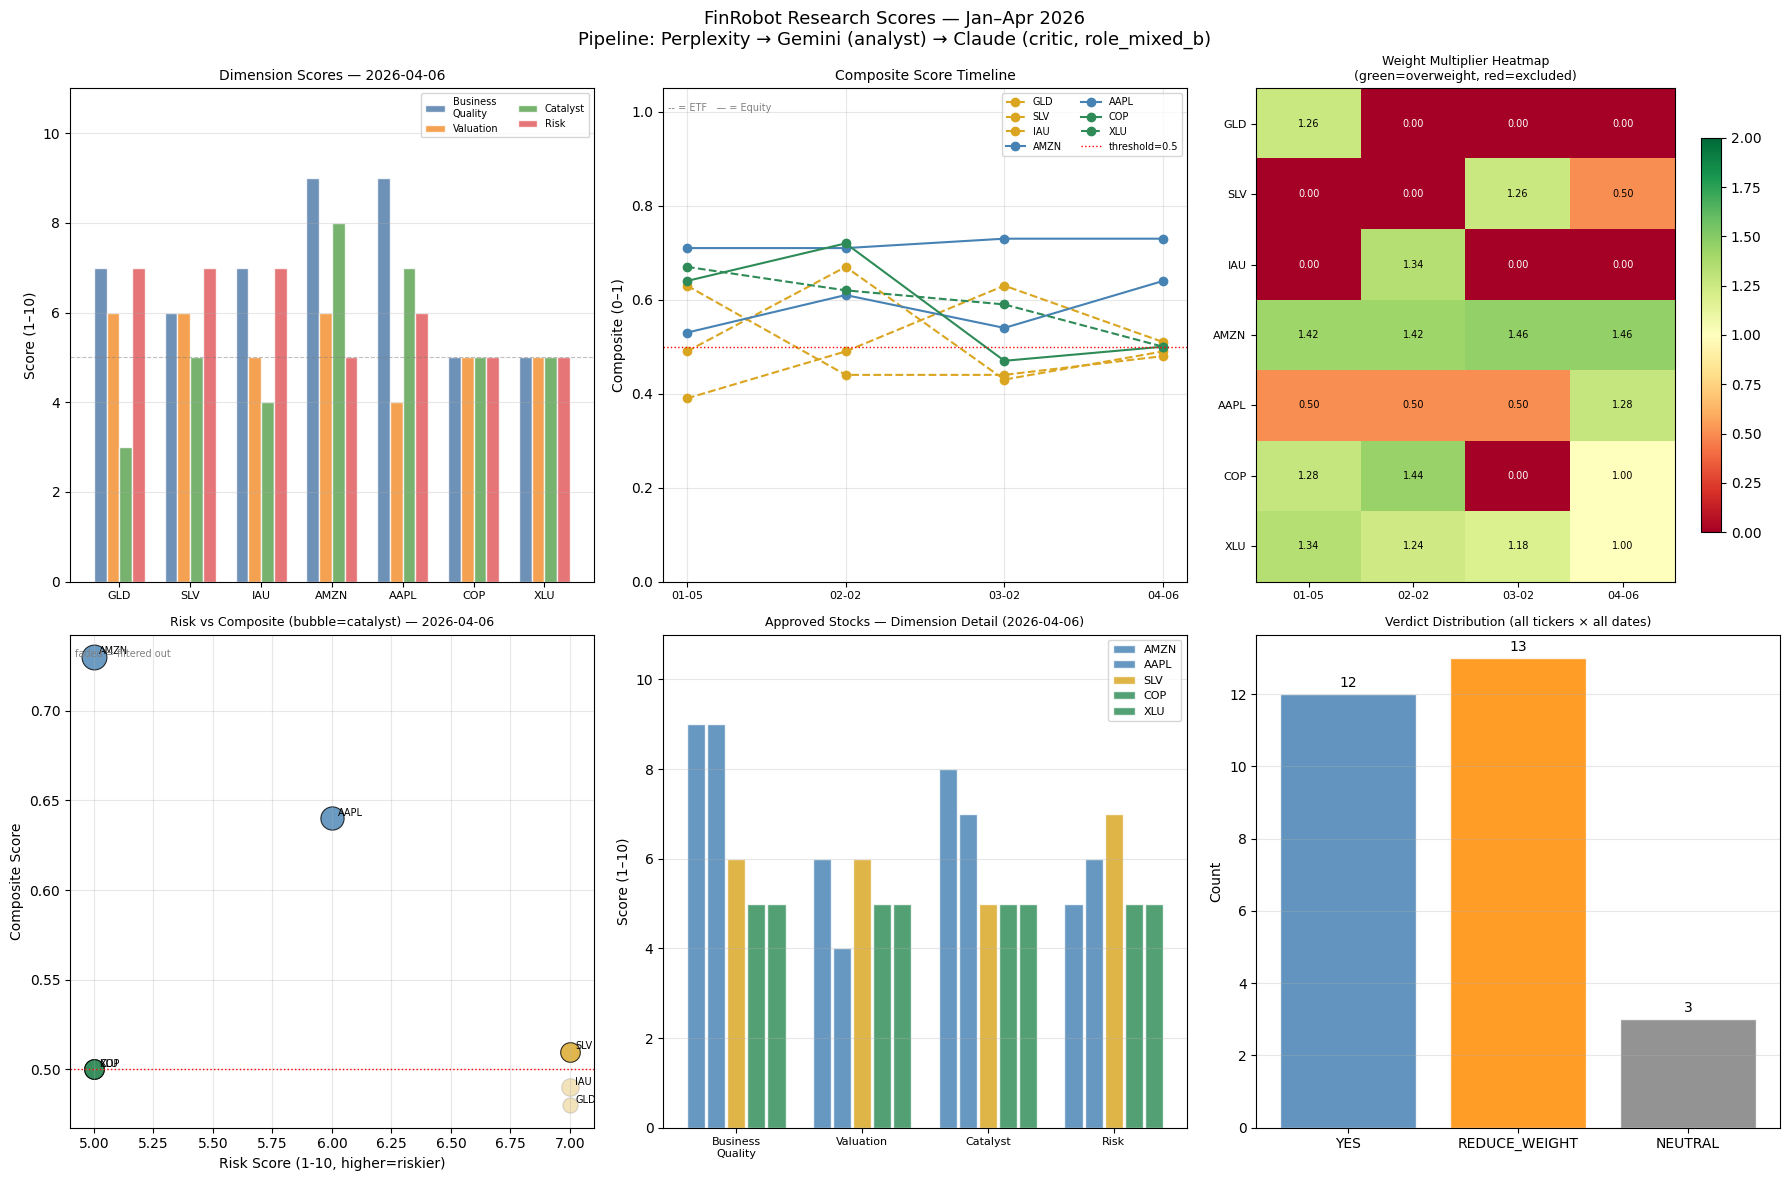

Saved: finrobot_v3_results.png


In [14]:
import numpy as np

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    "FinRobot Research Scores — Jan–Apr 2026\n"
    "Pipeline: Perplexity → Gemini (analyst) → Claude (critic, role_mixed_b)",
    fontsize=13
)

DIMS  = ["business_quality", "valuation", "catalyst", "risk"]
DIM_L = ["Business\nQuality", "Valuation", "Catalyst", "Risk"]
PALETTE = {
    "Precious Metals":    "goldenrod",
    "Tech / Consumer":    "steelblue",
    "Energy / Utilities": "seagreen",
}
TICKER_COLOR = {
    t: PALETTE[g]
    for g, ts in UNIVERSE.items() for t in ts
}

# Use last available date for dimension plots
latest_date = REBALANCE_DATES[-1]
latest_df   = all_scores[latest_date]

# ── Top-left: grouped bar chart — 4 dimensions per ticker (latest date) ───────
ax1 = fig.add_subplot(2, 3, 1)
tickers = ALL_CANDIDATES
x       = np.arange(len(tickers))
w       = 0.18
dim_colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]

for di, (dim, dlabel) in enumerate(zip(DIMS, DIM_L)):
    vals = [latest_df.loc[t, dim] if t in latest_df.index else 5.0 for t in tickers]
    ax1.bar(x + di*w - 1.5*w, vals, w, label=dlabel,
            color=dim_colors[di], alpha=0.82, edgecolor="white")

ax1.set_title(f"Dimension Scores — {latest_date}", fontsize=10)
ax1.set_ylabel("Score (1–10)")
ax1.set_ylim(0, 11)
ax1.set_xticks(x)
ax1.set_xticklabels(tickers, fontsize=8)
ax1.axhline(5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.legend(fontsize=7, ncol=2)
ax1.grid(axis="y", alpha=0.3)

# ── Top-middle: composite score timeline ──────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
for ticker in ALL_CANDIDATES:
    comps = [all_scores[d].loc[ticker, "composite"]
             if ticker in all_scores[d].index else None
             for d in REBALANCE_DATES]
    ls = "--" if ticker in ETF_TICKERS else "-"
    ax2.plot(range(len(REBALANCE_DATES)), comps,
             marker="o", linestyle=ls, linewidth=1.5,
             color=TICKER_COLOR[ticker], label=ticker)

ax2.axhline(QUALITY_THRESHOLD, color="red", linestyle=":", linewidth=1,
            label=f"threshold={QUALITY_THRESHOLD}")
ax2.set_title("Composite Score Timeline", fontsize=10)
ax2.set_ylabel("Composite (0–1)")
ax2.set_ylim(0, 1.05)
ax2.set_xticks(range(len(REBALANCE_DATES)))
ax2.set_xticklabels([d[5:] for d in REBALANCE_DATES], fontsize=8)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(alpha=0.3)
ax2.text(0.01, 0.97, "-- = ETF   — = Equity",
         transform=ax2.transAxes, fontsize=7, va="top", color="gray")

# ── Top-right: weight multiplier heatmap ──────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
wmult_data = np.array([
    [all_scores[d].loc[t, "weight_mult"] if t in all_scores[d].index else 0.0
     for d in REBALANCE_DATES]
    for t in ALL_CANDIDATES
])
im = ax3.imshow(wmult_data, cmap="RdYlGn", aspect="auto",
                vmin=0, vmax=2)
ax3.set_xticks(range(len(REBALANCE_DATES)))
ax3.set_xticklabels([d[5:] for d in REBALANCE_DATES], fontsize=8)
ax3.set_yticks(range(len(ALL_CANDIDATES)))
ax3.set_yticklabels(ALL_CANDIDATES, fontsize=8)
for i in range(len(ALL_CANDIDATES)):
    for j in range(len(REBALANCE_DATES)):
        ax3.text(j, i, f"{wmult_data[i,j]:.2f}",
                 ha="center", va="center", fontsize=7,
                 color="black" if 0.3 < wmult_data[i,j] < 1.7 else "white")
plt.colorbar(im, ax=ax3, shrink=0.8)
ax3.set_title("Weight Multiplier Heatmap\n(green=overweight, red=excluded)", fontsize=9)

# ── Bottom-left: risk vs composite bubble chart ────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
for ticker in ALL_CANDIDATES:
    row  = latest_df.loc[ticker] if ticker in latest_df.index else None
    if row is None: continue
    cat  = row["catalyst"]
    risk = row["risk"]
    comp = row["composite"]
    approved = row["approved"]
    c = TICKER_COLOR[ticker]
    ax4.scatter(risk, comp, s=cat*40, color=c,
                alpha=0.8 if approved else 0.3,
                edgecolors="black" if approved else "gray", linewidth=0.8)
    ax4.annotate(ticker, (risk, comp), fontsize=7,
                 xytext=(4, 2), textcoords="offset points")
ax4.axhline(QUALITY_THRESHOLD, color="red", linestyle=":", linewidth=1)
ax4.set_xlabel("Risk Score (1-10, higher=riskier)")
ax4.set_ylabel("Composite Score")
ax4.set_title(f"Risk vs Composite (bubble=catalyst) — {latest_date}", fontsize=9)
ax4.grid(alpha=0.3)
ax4.text(0.01, 0.97, "faded = filtered out",
         transform=ax4.transAxes, fontsize=7, va="top", color="gray")

# ── Bottom-middle: mean dimension radar (approved tickers, latest date) ────────
ax5 = fig.add_subplot(2, 3, 5)
approved_tickers = latest_df[latest_df["approved"]].index.tolist()
bar_x = np.arange(len(DIMS))
bw = 0.8 / max(len(approved_tickers), 1)
for i, ticker in enumerate(approved_tickers):
    row  = latest_df.loc[ticker]
    vals = [row[d] for d in DIMS]
    off  = (i - len(approved_tickers)/2 + 0.5) * bw
    ax5.bar(bar_x + off, vals, bw*0.9,
            color=TICKER_COLOR.get(ticker, "gray"),
            alpha=0.82, edgecolor="white", label=ticker)

ax5.set_title(f"Approved Stocks — Dimension Detail ({latest_date})", fontsize=9)
ax5.set_xticks(bar_x)
ax5.set_xticklabels(DIM_L, fontsize=8)
ax5.set_ylabel("Score (1–10)")
ax5.set_ylim(0, 11)
ax5.legend(fontsize=8)
ax5.grid(axis="y", alpha=0.3)

# ── Bottom-right: verdict breakdown ───────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
vc = {"YES": 0, "NO": 0, "REDUCE_WEIGHT": 0, "NEUTRAL": 0}
for sdf in all_scores.values():
    for v in sdf["verdict"]:
        vc[v] = vc.get(v, 0) + 1
vcols = {"YES": "steelblue", "NO": "tomato",
         "REDUCE_WEIGHT": "darkorange", "NEUTRAL": "gray"}
labels = [k for k, v in vc.items() if v > 0]
vals_v = [vc[k] for k in labels]
bars6  = ax6.bar(labels, vals_v,
                 color=[vcols[l] for l in labels],
                 alpha=0.85, edgecolor="white")
ax6.bar_label(bars6, fontsize=10, padding=3)
ax6.set_title("Verdict Distribution (all tickers × all dates)", fontsize=9)
ax6.set_ylabel("Count")
ax6.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("finrobot_v3_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: finrobot_v3_results.png")

#### 14. Save All Results

In [17]:
output = {
    "pipeline":          "Perplexity → Gemini analyst → Claude critic (role_mixed_b)",
    "backtest_window":   "2026-01-01 to 2026-04-30",
    "rebalance_dates":   REBALANCE_DATES,
    "universe":          UNIVERSE,
    "quality_threshold": QUALITY_THRESHOLD,
    "score_formula":     "composite = (BQ×0.30 + VAL×0.20 + CAT×0.30 + (10-RISK)×0.20) / 10",
    "weight_formula":    "mult = 1.0 + (composite - 0.5) × 2.0  [clamped: NO→0, REDUCE→≤0.5]",
    "by_date": {
        date: {
            "scorecard": all_scores[date].reset_index().to_dict(orient="records"),
            "reports": {
                t: {
                    "final_report": res.get("final_report", ""),
                    "composite":    res.get("composite"),
                    "verdict":      res.get("verdict"),
                    "weight_mult":  res.get("weight_mult"),
                }
                for t, res in all_results[date].items()
            }
        }
        for date in REBALANCE_DATES
    }
}

with open("finrobot_v3_results.json", "w") as f:
    json.dump(output, f, indent=2, default=str)

print("Saved: finrobot_v3_results.json")
print("Saved: finrobot_v3_results.png")
print("\nFinal scorecards:")
for date, sdf in all_scores.items():
    approved = sdf[sdf["approved"]].index.tolist()
    print(f"  {date}: approved={approved}")

Saved: finrobot_v3_results.json
Saved: finrobot_v3_results.png

Final scorecards:
  2026-01-05: approved=['AMZN', 'XLU', 'COP', 'GLD', 'AAPL']
  2026-02-02: approved=['COP', 'AMZN', 'IAU', 'XLU', 'AAPL']
  2026-03-02: approved=['AMZN', 'SLV', 'XLU', 'AAPL']
  2026-04-06: approved=['AMZN', 'AAPL', 'SLV', 'COP', 'XLU']


---
## Architecture Summary — v3

### ResearchScore dimensions

| Dimension | Weight | Measures | ETF equivalent |
|---|---|---|---|
| Business Quality | 30% | Moat, revenue quality, margins | Macro regime quality, fund flow trend |
| Valuation | 20% | Price vs fair value | ETF premium/discount to NAV, yield vs bonds |
| Catalyst | 30% | Near-term catalyst strength | Macro catalyst (rate decision, inflation print) |
| Risk (inverted) | 20% | Downside risks | Macro tail risks, rate sensitivity |

### Composite score → weight multiplier

```
composite = (BQ×0.30 + VAL×0.20 + CAT×0.30 + (10−RISK)×0.20) / 10   ∈ [0, 1]
mult      = 1.0 + (composite − 0.5) × 2.0                            ∈ [0, 2]

Examples:
  composite=0.80  →  mult=1.60  (overweight)
  composite=0.50  →  mult=1.00  (neutral, no change)
  composite=0.30  →  mult=0.60  (underweight)
  verdict=NO      →  mult=0.00  (excluded)
```

### Pipeline integration
```
AdaptiveRotationEngine
  → STEP 3: intra_group_ranking  → base_weights
  → STEP 3.5 (FinRobot):
       run_filter_for_date()     → scores_df (4 dims + composite + weight_mult)
       apply_finrobot_weights()  → adjusted_weights
  → STEP 4–6: exception / risk / portfolio_builder (uses adjusted_weights)
  → Backtest vs SPY
```